In [1]:
from dataclasses import dataclass
from enum import StrEnum
from datetime import datetime, timedelta, date
import polars as pl
from collections import defaultdict, Counter
from typing import Tuple
from common.constants.column_types import (
    CPZP_SCHEMA,
    OZP_SCHEMA,
    POHLAVI_CPZP,
    TYP_UDALOSTI,
)
from common.constants.column_names import SHARED_COLUMNS, OZP_COLUMNS, CPZP_COLUMNS
import pickle
from common.constants.objects import (
    Person,
    Gender,
    AgeCohort,
    Prescription,
    PrescriptionType,
)
import matplotlib.pyplot as plt
import numpy as np
import os
from common.utils import (
    draw_chart,
    filter_by_date_range,
)
from bisect import bisect_left, bisect_right
import random

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(60)

pl.Config.set_tbl_rows(-1)


ZACATEK_POJISTENI = date(2015, 1, 1)
KONEC_POJISTENI = date(2023, 12, 31)


class AgeCohort(StrEnum):
    _12_15 = "12-15"
    _16_29 = "16-29"
    _30_49 = "30-49"
    _50_59 = "50-59"
    IRRELEVANT = "irrelevant"


def calculate_age_cohort(person: Person) -> AgeCohort:
    YEAR_FOR_AGE_CALCULATION = 2021

    age = YEAR_FOR_AGE_CALCULATION - person.born_at.year
    if age >= 12 and age <= 15:
        return AgeCohort._12_15
    elif age >= 16 and age <= 29:
        return AgeCohort._16_29
    elif age >= 30 and age <= 49:
        return AgeCohort._30_49
    elif age >= 50 and age <= 59:
        return AgeCohort._50_59
    else:
        return AgeCohort.IRRELEVANT


def is_injection(pr: Prescription) -> bool:
    return pr.lekova_forma_zkr and (pr.lekova_forma_zkr.startswith("INJ"))


def create_prednison_enum(step: int = 25, max_value: int = 5000):
    values = {"ZERO": "zero", f"MORE_THAN_{max_value}": f"more_than_{max_value}"}

    for start in range(0, max_value, step):
        end = start + step
        name = f"BETWEEN_{start}_AND_{end}"
        values[name] = name.lower()

    return StrEnum("PREDNISON_EQUIV_CATEGORY", values)


PREDNISON_EQUIV_CATEGORY = create_prednison_enum()


def from_prednison_equiv(prednison_equiv: float) -> PREDNISON_EQUIV_CATEGORY:
    if prednison_equiv == 0:
        return PREDNISON_EQUIV_CATEGORY.ZERO

    step = 25
    max_value = 5000

    if prednison_equiv >= max_value:
        return PREDNISON_EQUIV_CATEGORY[f"MORE_THAN_{max_value}"]

    start = int((prednison_equiv // step) * step)
    end = start + step
    name = f"BETWEEN_{start}_AND_{end}"
    return PREDNISON_EQUIV_CATEGORY[name]


def find_matching_person(
    vax_person: Person,
    pe_range: PREDNISON_EQUIV_CATEGORY,
    vax_date: datetime,
    novax_map: dict[PREDNISON_EQUIV_CATEGORY, dict[AgeCohort, dict[Gender, set[int]]]],
) -> str:
    ac = calculate_age_cohort(vax_person)
    gender = vax_person.gender
    novax_matched_ids = novax_map[vax_date][pe_range][ac][gender]
    max_int = len(novax_matched_ids)
    random_index = random.randint(0, max_int - 1)
    return novax_matched_ids[random_index]


def sum_after_date_pe_for_person(person: Person, ddate: datetime) -> float:
    return sum(
        pr.prednison_equiv
        for pr in person.prescriptions
        if (not is_injection(pr))
        and (pr.date > ddate and pr.date < ddate + timedelta(days=365))
    )


def sum_before_date_pe_for_person(person: Person, ddate: datetime) -> float:
    return sum(
        pr.prednison_equiv
        for pr in person.prescriptions
        if (not is_injection(pr))
        and (pr.date > ddate - timedelta(days=365) and pr.date < ddate)
    )

In [2]:
POJISTOVNA = "cpzp"
with open(f"./DATACON_data/{POJISTOVNA}_persons.pkl", "rb") as f:
    persons: list[Person] = pickle.load(f)

In [3]:
novax_persons_to_analyse = [
    p
    for p in persons
    if not p.vaccines
    and p.died_at is None
    and (
        p.zahajeni_pojisteni < ZACATEK_POJISTENI
        and p.ukonceni_pojisteni > KONEC_POJISTENI
    )
]

person_map = {p.id: p for p in persons}
vax_people = [
    p
    for p in persons
    if p.vaccines
    and p.died_at is None  # klidně do roku 2023
    and (
        p.zahajeni_pojisteni < ZACATEK_POJISTENI
        and p.ukonceni_pojisteni > KONEC_POJISTENI
    )
]

anchor_dates = [
    (datetime(2021, 1, 1) + timedelta(days=i)).date()
    for i in range((datetime(2022, 2, 28) - datetime(2021, 1, 1)).days + 1)
]

vax_dates_distribution: dict[AgeCohort, dict[datetime, float]] = defaultdict(
    lambda: defaultdict(float)
)

for vax_person in vax_people:
    ac = calculate_age_cohort(vax_person)
    vax_date = vax_person.vaccines[0].date
    vax_dates_distribution[ac][vax_date] += 1


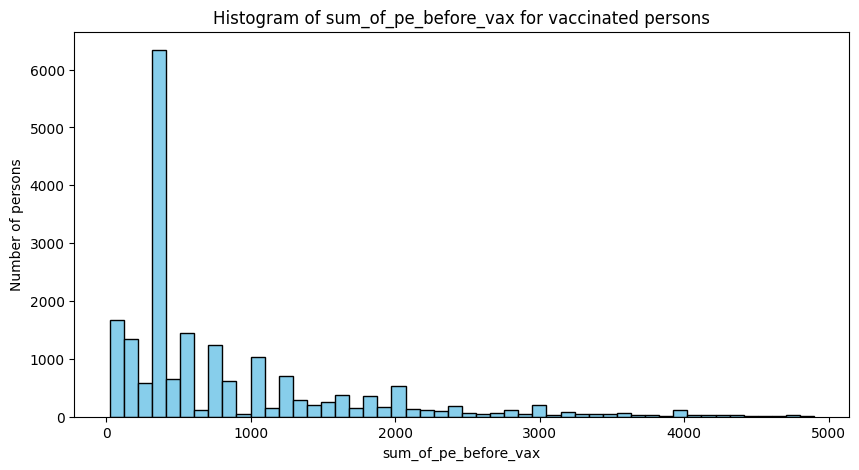

In [ ]:
sum_of_pe_before_vax_values = [
    p.sum_of_pe_before_vax
    for p in vax_people
    if p.sum_of_pe_before_vax < 5000 and p.sum_of_pe_before_vax > 0
]

plt.figure(figsize=(10, 5))
plt.hist(sum_of_pe_before_vax_values, bins=50, color="skyblue", edgecolor="black")
plt.title("Histogram of sum_of_pe_before_vax for vaccinated persons")
plt.xlabel("sum_of_pe_before_vax")
plt.ylabel("Number of persons")
plt.show()

# 0, 1-500, 500-5000, kyblíčková analýza
# dát pryč 5000+


In [ ]:
def compute_prednison_windows(
    people: list[Person], vax_anchor_dates: list[datetime]
) -> dict[datetime, dict[str | int, float]]:
    # Prepare output structure
    result: dict[
        datetime,
        dict[PREDNISON_EQUIV_CATEGORY, dict[AgeCohort, dict[Gender, set[int]]]],
    ] = {ad: {} for ad in vax_anchor_dates}

    completed_persons = 0
    len_of_persons_to_analyse = len(people)
    for person in people:
        completed_persons += 1
        print(
            f"Processing person {completed_persons}/{len_of_persons_to_analyse}",
            end="\r",
        )

        # person_prescriptions = sorted(person.prescriptions, key=lambda pr: pr.date)
        person_prescriptions = [
            pr
            for pr in sorted(person.prescriptions, key=lambda pr: pr.date)
            if not (is_injection(pr))
        ]
        if not person_prescriptions:
            # no prescriptions → all anchor dates = 0
            for anchor in vax_anchor_dates:
                # result[ad][person.id] = 0.0
                pe_range = from_prednison_equiv(0)
                if pe_range not in result[anchor]:
                    result[anchor][pe_range] = {}

                ac = calculate_age_cohort(person)
                if ac not in result[anchor][pe_range]:
                    result[anchor][pe_range][ac] = {}

                if person.gender not in result[anchor][pe_range][ac]:
                    result[anchor][pe_range][ac][person.gender] = set()

                result[anchor][pe_range][ac][person.gender].add(person.id)
            continue

        # For accumulation:
        # Each anchor date holds its sum of prednison for this person
        per_person_map: dict[datetime, float] = {ad: 0.0 for ad in vax_anchor_dates}

        # 3) For each prescription, add its value to all anchor dates
        #    within pr.date → pr.date + 365 days
        for pr in person_prescriptions:
            start = pr.date
            end = pr.date + timedelta(days=365)

            # indices of anchor dates inside [start, end]
            i = bisect_left(vax_anchor_dates, start)
            j = bisect_right(vax_anchor_dates, end)

            # Add prednison_equiv to each matching anchor date
            for idx in range(i, j):
                anchor = vax_anchor_dates[idx]
                per_person_map[anchor] += pr.prednison_equiv

        # Store per-person results
        for anchor, value in per_person_map.items():
            # result[anchor][person.id] = value
            pe_range = from_prednison_equiv(value)
            if pe_range not in result[anchor]:
                result[anchor][pe_range] = {}

            ac = calculate_age_cohort(person)
            if ac not in result[anchor][pe_range]:
                result[anchor][pe_range][ac] = {}

            if person.gender not in result[anchor][pe_range][ac]:
                result[anchor][pe_range][ac][person.gender] = set()

            result[anchor][pe_range][ac][person.gender].add(person.id)

    for anchor, ranges in result.items():
        for pe_range, acs in ranges.items():
            for ac, genders in acs.items():
                for gender, idset in genders.items():
                    genders[gender] = list(idset)

    return result


pe_map = compute_prednison_windows(novax_persons_to_analyse, anchor_dates)


In [5]:
# import pickle

# with open('pe_map.pkl', 'wb') as f:
#     pickle.dump(pe_map, f)


import pickle

with open("pe_map.pkl", "rb") as f:
    pe_map = pickle.load(f)


In [6]:
def compute_vax_vs_novax_sums(people):
    vax_before_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    vax_after_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    novax_before_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    novax_after_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    print("iterating through people ", len(people))
    for person in people:
        first_vax = person.vaccines[0]
        vax_person_before_pe = sum_before_date_pe_for_person(person, first_vax.date)
        if vax_person_before_pe > 5000:
            continue
        vax_person_after_pe = sum_after_date_pe_for_person(person, first_vax.date)

        pe_range = from_prednison_equiv(vax_person_before_pe)
        try:
            matched_id = find_matching_person(person, pe_range, first_vax.date, pe_map)
        except Exception:
            continue

        novax_person_before_pe = sum_before_date_pe_for_person(
            person_map[matched_id], first_vax.date
        )
        novax_person_after_pe = sum_after_date_pe_for_person(
            person_map[matched_id], first_vax.date
        )

        ac = calculate_age_cohort(person)
        vax_before_pe_map[ac][first_vax.date] += vax_person_before_pe
        vax_after_pe_map[ac][first_vax.date] += vax_person_after_pe
        novax_before_pe_map[ac][first_vax.date] += novax_person_before_pe
        novax_after_pe_map[ac][first_vax.date] += novax_person_after_pe

    return vax_before_pe_map, vax_after_pe_map, novax_before_pe_map, novax_after_pe_map

In [22]:
EffectMap = dict[AgeCohort, dict[datetime, float]]


def run_matching_analysis(
    people,
    num_runs: int = 100,
) -> Tuple[EffectMap, EffectMap, dict[AgeCohort, dict[datetime, list[float]]]]:
    effects: dict[AgeCohort, dict[datetime, list[float]]] = defaultdict(
        lambda: defaultdict(list)
    )

    for i in range(num_runs):
        vax_before, vax_after, novax_before, novax_after = compute_vax_vs_novax_sums(
            people
        )

        result_map = compute_effect_values(
            vax_before, vax_after, novax_before, novax_after
        )

        for cohort, date_map in result_map.items():
            for dt, value in date_map.items():
                effects[cohort][dt].append(value)

        print(f"Processed {i} runs")

    median_map, iqr_map = compute_statistics(effects)

    return median_map, iqr_map, effects


def compute_effect_values(
    vax_before_pe_map,
    vax_after_pe_map,
    novax_before_pe_map,
    novax_after_pe_map,
) -> EffectMap:
    result_map: EffectMap = defaultdict(dict)

    cohorts = (
        set(vax_before_pe_map.keys())
        | set(vax_after_pe_map.keys())
        | set(novax_before_pe_map.keys())
        | set(novax_after_pe_map.keys())
    )

    for cohort in cohorts:
        all_dates = (
            set(vax_before_pe_map[cohort].keys())
            | set(vax_after_pe_map[cohort].keys())
            | set(novax_before_pe_map[cohort].keys())
            | set(novax_after_pe_map[cohort].keys())
        )

        for dt in all_dates:
            vax_before = vax_before_pe_map[cohort].get(dt, 0.0)
            vax_after = vax_after_pe_map[cohort].get(dt, 0.0)
            novax_before = novax_before_pe_map[cohort].get(dt, 0.0)
            novax_after = novax_after_pe_map[cohort].get(dt, 0.0)

            if vax_after != 0 and novax_after != 0:
                res = (vax_before / vax_after) - (novax_before / novax_after)
                # res = vax_after / novax_after
                result_map[cohort][dt] = res

    return result_map


def compute_statistics(
    effects: dict[AgeCohort, dict[datetime, list[float]]],
) -> tuple[EffectMap, EffectMap]:
    median_map: EffectMap = defaultdict(dict)
    iqr_map: dict[AgeCohort, dict[datetime, tuple[float, float]]] = defaultdict(dict)

    for cohort, date_map in effects.items():
        for dt, values in date_map.items():
            arr = np.array(values)

            median = np.median(arr)
            q1 = np.percentile(arr, 25)
            q3 = np.percentile(arr, 75)

            median_map[cohort][dt] = median
            iqr_map[cohort][dt] = (q1, q3)

    return median_map, iqr_map


five_hundred_to_five_thousand_pe_vax_people = [
    p
    for p in vax_people
    if sum_before_date_pe_for_person(p, p.vaccines[0].date) >= 1
    and sum_before_date_pe_for_person(p, p.vaccines[0].date) < 500
]


median_map, iqr_map, effects = run_matching_analysis(
    five_hundred_to_five_thousand_pe_vax_people
)


iterating through people  10192
Processed 0 runs
iterating through people  10192
Processed 1 runs
iterating through people  10192
Processed 2 runs
iterating through people  10192
Processed 3 runs
iterating through people  10192
Processed 4 runs
iterating through people  10192
Processed 5 runs
iterating through people  10192
Processed 6 runs
iterating through people  10192
Processed 7 runs
iterating through people  10192
Processed 8 runs
iterating through people  10192
Processed 9 runs
iterating through people  10192
Processed 10 runs
iterating through people  10192
Processed 11 runs
iterating through people  10192
Processed 12 runs
iterating through people  10192
Processed 13 runs
iterating through people  10192
Processed 14 runs
iterating through people  10192
Processed 15 runs
iterating through people  10192
Processed 16 runs
iterating through people  10192
Processed 17 runs
iterating through people  10192
Processed 18 runs
iterating through people  10192
Processed 19 runs
iterating 

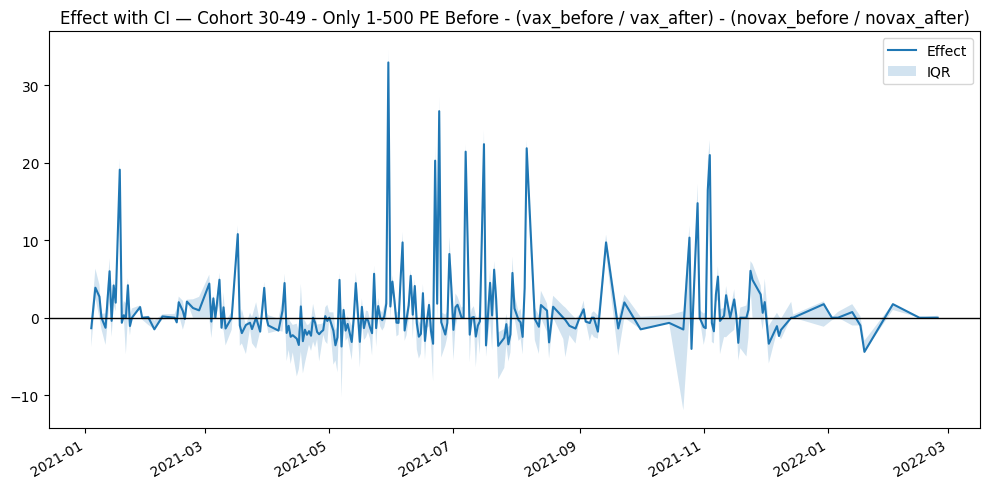

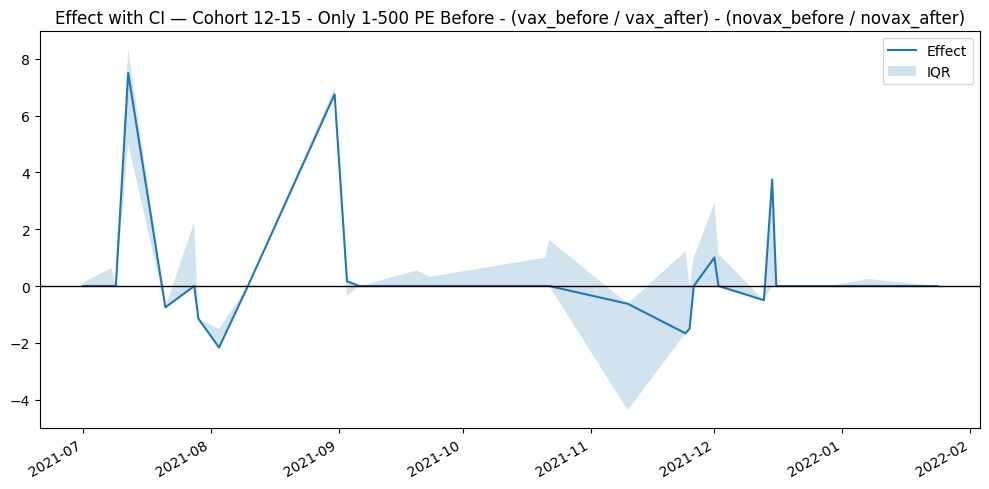

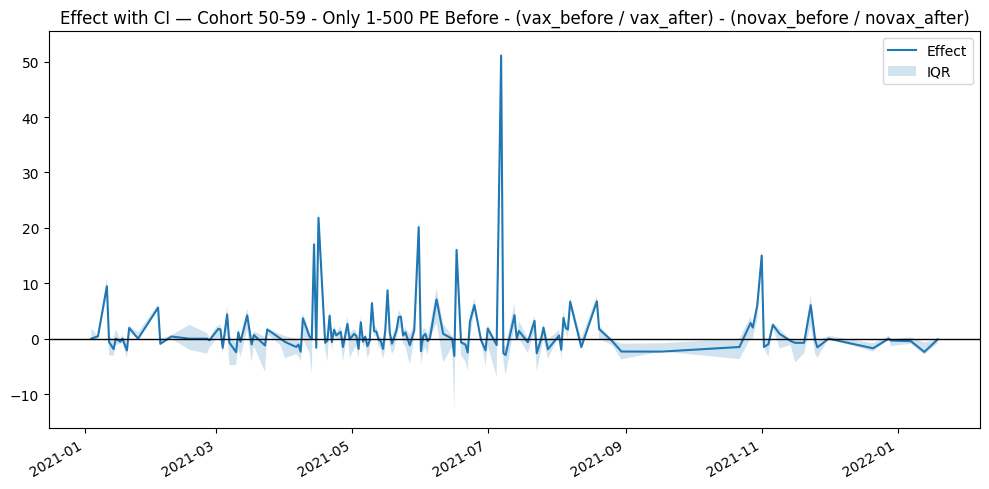

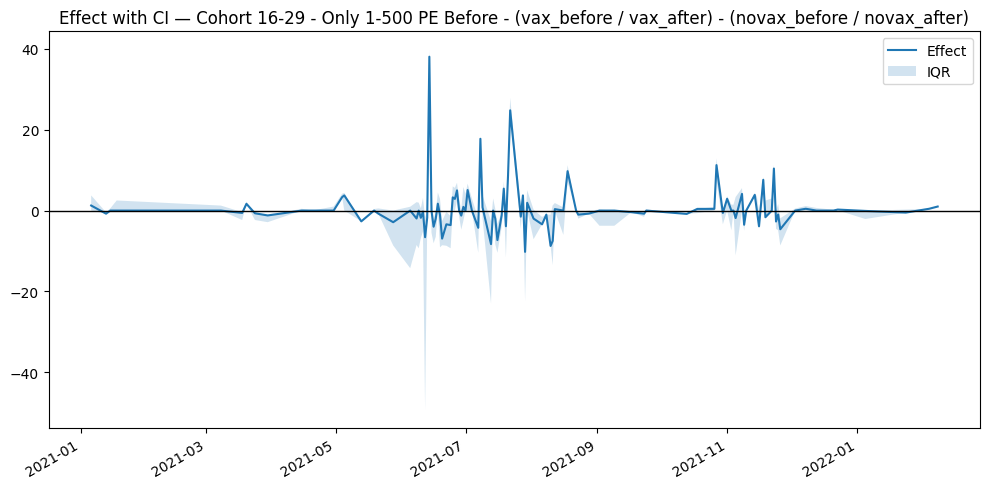

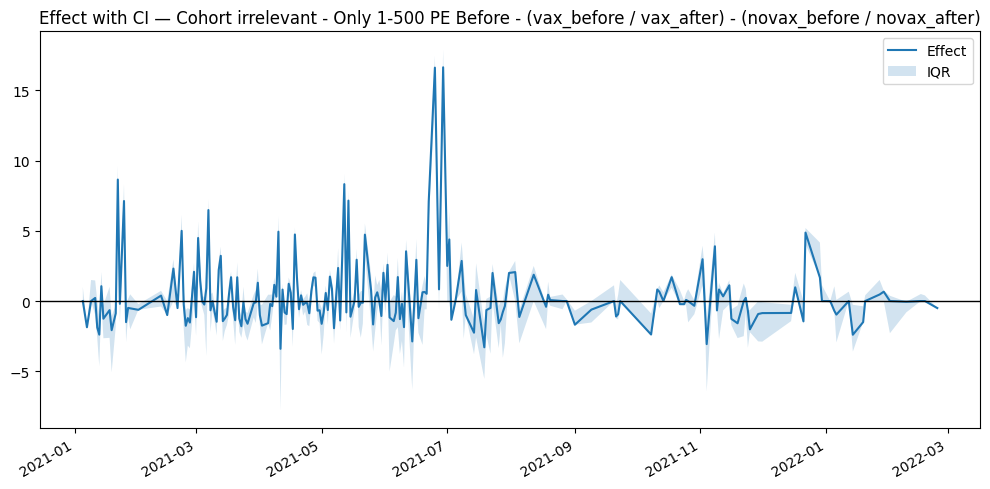

In [23]:
for cohort, date_map in median_map.items():
    sorted_dates = sorted(date_map.keys())
    y_mean = [median_map[cohort][d] for d in sorted_dates]
    y_lower = [iqr_map[cohort][d][0] for d in sorted_dates]
    y_upper = [iqr_map[cohort][d][1] for d in sorted_dates]

    fig, ax = plt.subplots(figsize=(10, 5))

    # plot mean
    ax.plot(sorted_dates, y_mean, label="Effect")

    # fill CI
    ax.fill_between(sorted_dates, y_lower, y_upper, alpha=0.2, label="IQR")

    ax.axhline(0, color="black", linewidth=1)

    ax.set_title(
        f"Effect with CI — Cohort {cohort} - Only 1-500 PE Before - (vax_before / vax_after) - (novax_before / novax_after)"
    )
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(f"runs/median_and_iqr/1_to_500_PE/effect_over_time_{cohort}.png")
    plt.show()
    plt.close(fig)

In [24]:
def get_week(dt: datetime) -> tuple[int, int]:
    iso = dt.isocalendar()
    return (iso[0], iso[1])  # year, weeknum


def aggregate_weekly_weighted(
    effects: dict[AgeCohort, dict[datetime, list[float]]],
    weights: dict[AgeCohort, dict[datetime, float]],
):
    weekly_median = defaultdict(dict)
    weekly_iqr = defaultdict(dict)

    for cohort, date_map in effects.items():
        pooled = defaultdict(list)

        # pool values with weights
        for dt, values in date_map.items():
            w = int(weights[cohort].get(dt, 1.0))
            week = get_week(dt)

            # replicate bootstrap samples
            pooled[week].extend(values * w)

        # compute stats per week
        for week, vals in pooled.items():
            if not vals:
                continue

            arr = np.array(vals)

            median = np.median(arr)
            q1 = np.percentile(arr, 25)
            q3 = np.percentile(arr, 75)

            weekly_median[cohort][week] = median
            weekly_iqr[cohort][week] = (q1, q3)

    return weekly_median, weekly_iqr


def compute_weights(vax_people):
    weights: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )

    for p in vax_people:
        ac = calculate_age_cohort(p)
        dt = p.vaccines[0].date
        weights[ac][dt] += 1

    return weights


def plot_weekly(weekly_median, weekly_iqr):
    for cohort, week_map in weekly_median.items():
        sorted_weeks = sorted(week_map.keys())

        y_med = [weekly_median[cohort][w] for w in sorted_weeks]
        y_q1 = [weekly_iqr[cohort][w][0] for w in sorted_weeks]
        y_q3 = [weekly_iqr[cohort][w][1] for w in sorted_weeks]

        labels = [f"{yr}-W{wk}" for (yr, wk) in sorted_weeks]

        fig, ax = plt.subplots(figsize=(12, 6))

        ax.plot(labels, y_med, label="Median effect")
        ax.fill_between(labels, y_q1, y_q3, alpha=0.2, label="IQR")

        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(
            f"Weighted weekly effect — Cohort {cohort} - Only 1-500 PE Before - (vax_before / vax_after) - (novax_before / novax_after)"
        )
        ax.set_ylabel("Effect")
        ax.set_xlabel("Week")

        plt.xticks(rotation=45)
        ax.legend()
        plt.tight_layout()
        fig.savefig(
            f"runs/median_and_iqr/1_to_500_PE/weighted_weekly_effect_{cohort}.png"
        )
        plt.show()


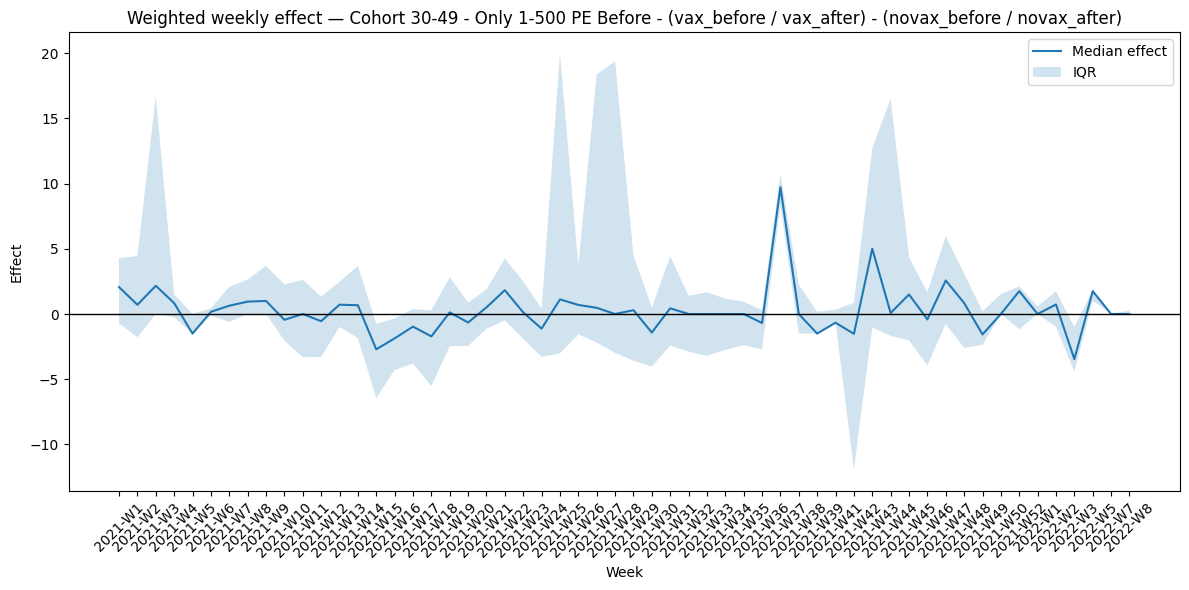

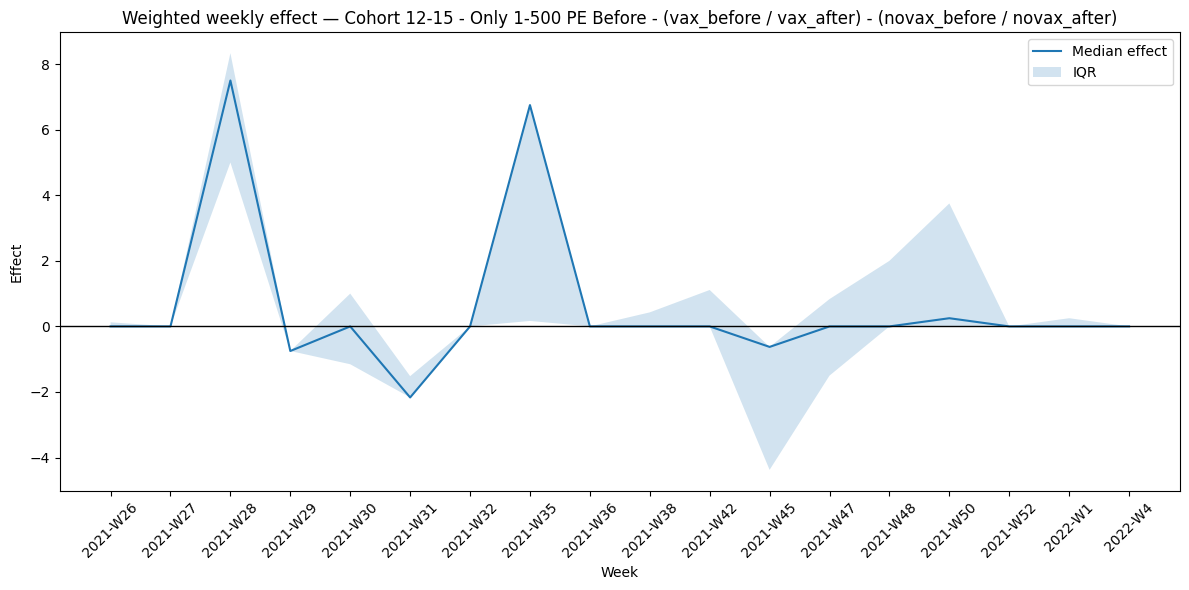

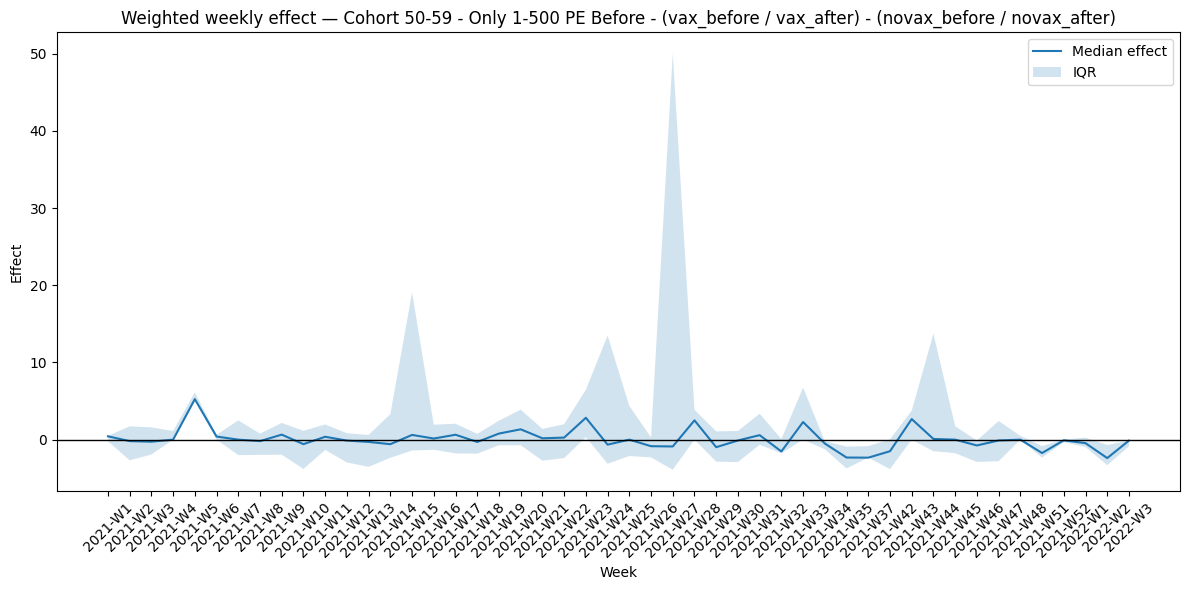

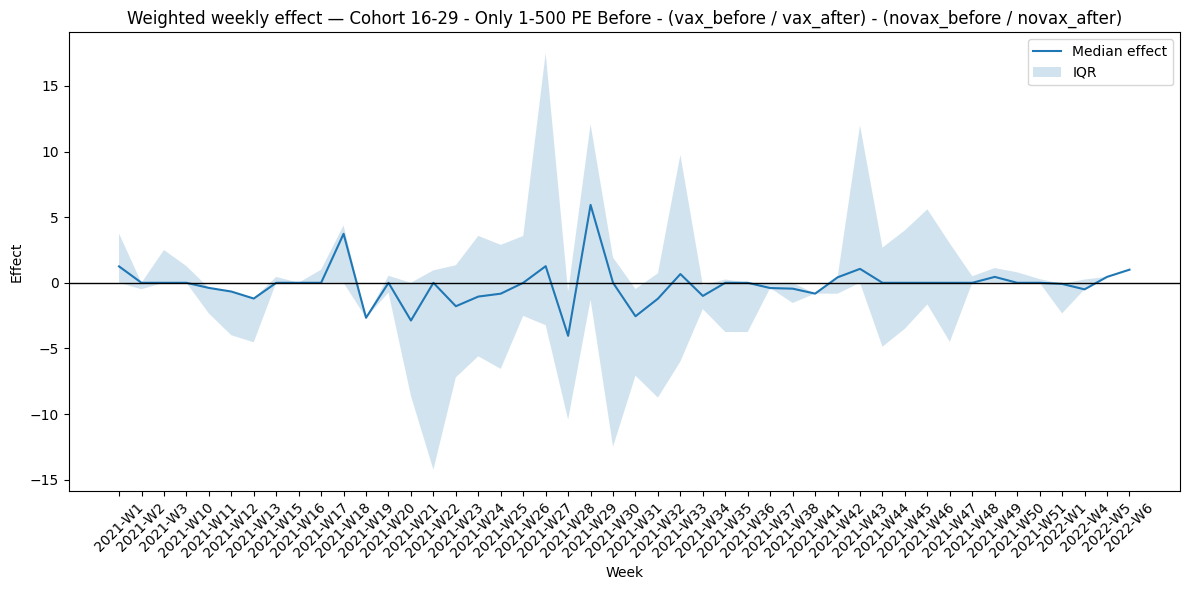

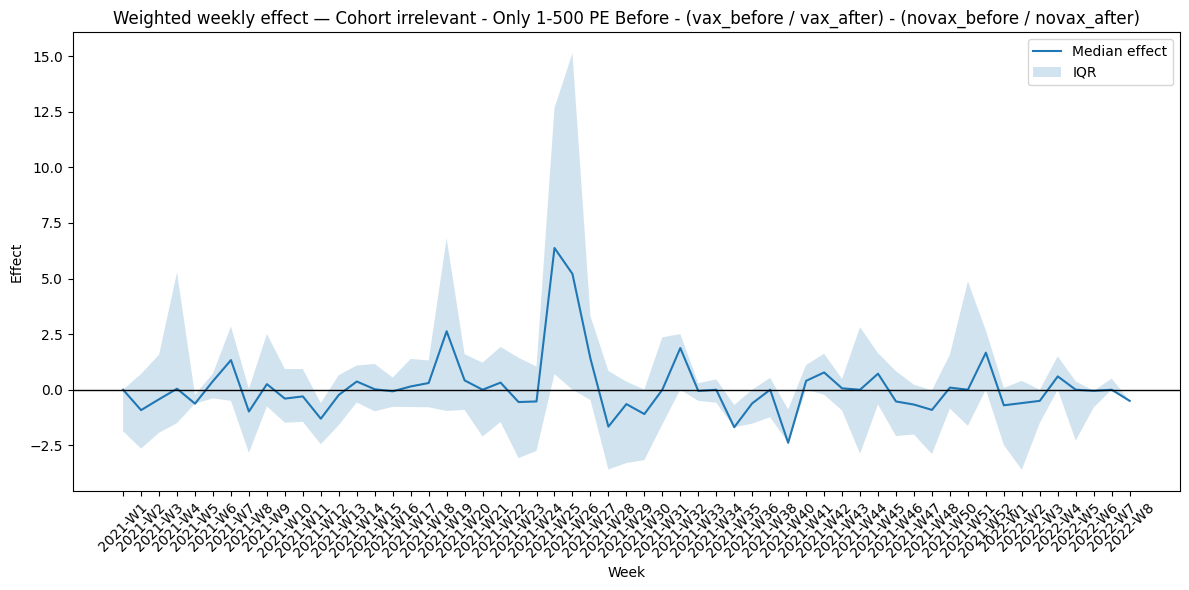

In [25]:
weights = compute_weights(vax_people)
weekly_median, weekly_iqr = aggregate_weekly_weighted(
    effects,
    weights,
)
plot_weekly(weekly_median, weekly_iqr)


In [16]:
for cohort, date_map in result_map.items():
    sorted_dates = sorted(date_map.keys())
    sorted_values = [date_map[d] for d in sorted_dates]

    vax_counts = [vax_dates_distribution[cohort].get(d, 0) for d in sorted_dates]

    fig, ax_left = plt.subplots(figsize=(10, 5))

    ax_left.plot(sorted_dates, sorted_values, label="Effect", color="blue")
    ax_left.axhline(0, color="black", linewidth=1)
    ax_left.set_xlabel("Date")
    ax_left.set_ylabel("Effect Value")
    ax_left.set_title(f"Effect Over Time — Cohort: {cohort}")

    ax_right = ax_left.twinx()
    ax_right.plot(
        sorted_dates,
        vax_counts,
        label="Vaccinated",
        linestyle="--",
        color="orange",  # ← your new color
    )
    ax_right.set_ylabel("Vaccinated Count")

    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(f"runs/4/effect_over_time_{cohort}.png")
    plt.close(fig)
